# Moore-Penrose pseudo inverse

The Moore-Penrose pseudoinverse is defined for any matrix and is unique.

In [18]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

Write a function computing the Moore-Penrose pseudo inverse, exploiting the full SVD.

$$A^\dagger = V \Sigma^{-1} U^T, \quad A = U \Sigma V^T$$


Task : perform least squares using Moore-Penrose pseudo inverse.

For pseudo inverse we use SVD

In [19]:
def my_pinv_fullSVD(A):
  # computing inverse of sigma
  #singular values greater than zero to invert.
  # la.diagsvd(s, A.shape[1], A.shape[0]) constructs the rectangular diagonal matrix of inverted singular values required to form the pseudoinverse using full SVD.
  U, s, VT = np.linalg.svd(A)
  s[s > 0] = 1 / s[s > 0]
  Pinv = VT.transpose() @ la.diagsvd(s, A.shape[1], A.shape[0]) @ U.transpose()
  return Pinv

Write now a function computing the Moore-Penrose pseudo inverse, exploiting the reduced/thin SVD.


In [20]:
def my_pinv_thinSVD(A):
  U, s, VT = np.linalg.svd(A, full_matrices=False)
  s[s > 0] = 1 / s[s > 0]
  Pinv =  (VT.transpose() * s) @ U.transpose()
  # or broadcasting Pinv = (VT.T *s) @ U.T
  return Pinv

Generate a random matrix $A$ (with elements sampled from a standard Gaussian distribution) with 5 rows and 4 columns. Compute its Moore-Penrose pseudo inverse thorugh the two functions above defined, and compare the result with the function `numpy.linalg.pinv` (see [Documentation](https://numpy.org/doc/stable/reference/generated/numpy.linalg.pinv.html)).


In [21]:
A = np.random.randn(5, 4)
Apinv_numpy = np.linalg.pinv(A)
Apinv_fullSVD = my_pinv_fullSVD(A)
Apinv_thinSVD = my_pinv_thinSVD(A)
print(np.linalg.norm(Apinv_numpy - Apinv_fullSVD) / np.linalg.norm(Apinv_numpy))
print(np.linalg.norm(Apinv_numpy - Apinv_thinSVD) / np.linalg.norm(Apinv_numpy))

1.220763753494872e-16
1.220763753494872e-16


Compare the three implementations performances through the Google Colab magic command `%timeit`.


In [22]:
%timeit np.linalg.pinv(A)

64.5 µs ± 12.2 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [23]:
%timeit my_pinv_fullSVD(A)

58.8 µs ± 18.7 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [24]:
%timeit my_pinv_thinSVD(A)

34.8 µs ± 988 ns per loop (mean ± std. dev. of 7 runs, 10000 loops each)


# Least Square Regression

Consider the linear model

$$
y = mx + q.
$$

where $m = 2$ and $q = 3$.

Generate $N = 100$ points $x_i$, sampling from a standard Gaussian distribution, and the associated $y_i$. Then, add a synthetic noise ($\epsilon_i$) by sampling from a Gaussian distribution with zero mean and standard deviation $\sigma = 2$. Plot the noisy data $(x_i, \tilde{y}_i)$, where $\tilde{y}_i = y_i + \epsilon_i$, in the $(x,y)$ plane, together with the line $y = mx + q$.


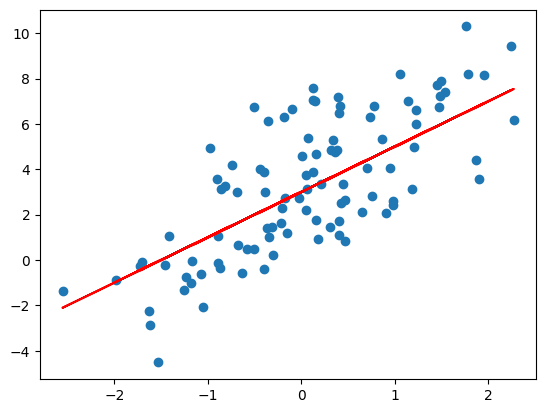

In [25]:
m = 2.0
q = 3.0
N = 100
noise = 2.0

np.random.seed(0)

# SOLUTION-BEGIN
X = np.random.randn(N)
Yreal = m * X + q
Y = Yreal+ noise * np.random.randn(N)
plt.scatter(X, Y)
plt.plot(X, m * X + q, color="red")
# SOLUTION-END

Using the previously implemented functions to compute the Moore-Penrose pseudo inverse, solve the least-squares problem

$$
\min_{m,q} \sum_{i=1}^N (\tilde{y}_i - (m x_i + q))^2
$$

and display the regression line superimposed to the noisy data and the exact model. Define

$$\Phi = [\mathbf{x}, \mathbf{1}] \in \mathbb R^{N \times 2}$$

The least square problem is

$$\Phi \mathbf{w} = \mathbf{y}$$

With solution

$$\mathbf{w} = \Phi^\dagger \mathbf{y}$$

where

$$\mathbf{w} = [\hat m, \hat q]$$

Notice that in general

$$\mathbf{y}^{Test} = \Phi^{Test} \mathbf{w}$$

that in our case is equivalent to

$$\mathbf{y}_i^{Test} = \hat{m} \mathbf{x}_i^{Test} + \hat{q}$$




here $$\Phi = [\mathbf{x}, \mathbf{1}] \in \mathbb R^{N \times 2}$$

because our y = mx + c, if we had used
$$\Phi = [\mathbf{x}]$$

then our y would be y = mx

[2.22939687 3.15030617]


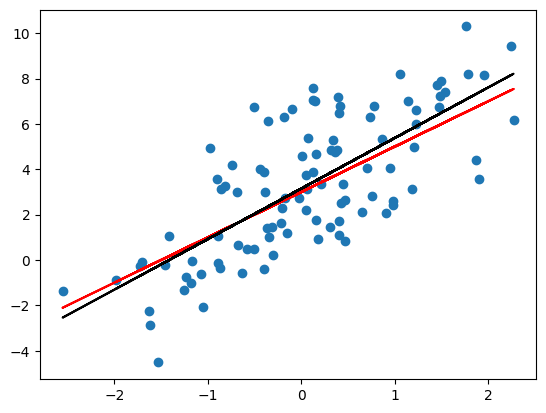

In [26]:
Phi = np.column_stack([X, np.ones((N,))])
w = my_pinv_thinSVD(Phi) @ Y
print(w)

plt.scatter(X, Y)
plt.plot(X, Yreal, 'r')
plt.plot(X, w[0]*X + w[1], 'k')

Repeat the excercise by solving the normal equations with `np.solve`.
$$(\Phi^T \Phi) \mathbf{w} = \Phi^T \mathbf{y}$$
Compare the results.


In [27]:
w2 = np.linalg.solve(Phi. T @ Phi, Phi.T @ Y)
print(np.linalg.norm(w2 - w))

8.881784197001252e-16


# Ridge regression and Kernel regression


Consider the function

$$
y = f(x) = \tanh(2x - 1).
$$

Generate $N = 100$ points $x_i$, sampling from a standard Gaussian distribution, and the associated $y_i$. Then, add a synthetic noise ($\epsilon_i$) by sampling from a Gaussian distribution with zero mean and standard deviation $\sigma = 0.1$. Plot the noisy data $(x_i, \tilde{y}_i)$, where $\tilde{y}_i = y_i + \epsilon_i$, in the $(x,y)$ plane.

Then, generate 1000 testing points, uniformly distributed in the interval $[-3,3]$, and display the function $y = f(x)$ in correspondence of the testing points.


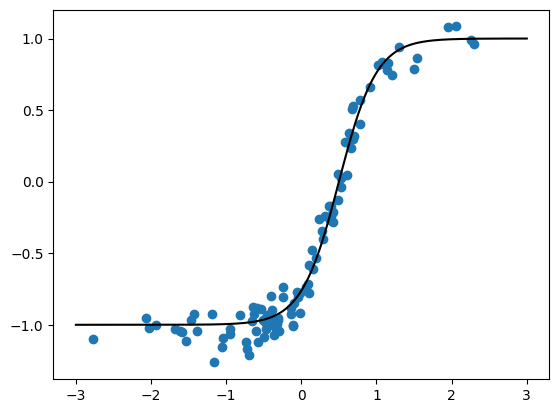

In [28]:
# Generating our data points
x = np.random.randn(100)
y_ex = np.tanh(2*x -1)
y = y_ex + 0.1 * np.random.randn(100) # std deviation 0.1 given above

# plt.scatter(x, y_ex) # s shaped
plt.scatter(x, y) # s shaped with noise

x_test = np.linspace(-3, 3, 1000)
y_test = np.tanh(2 * x_test -1)

plt.plot(x_test, y_test, 'k')


Proceeding as in the previous exercise, compute the regression line resulting from the **least squares regression** of data $(x_i, \tilde{y}_i)$. Plot the resulting regression line.


[ 0.64232246 -0.40373328]


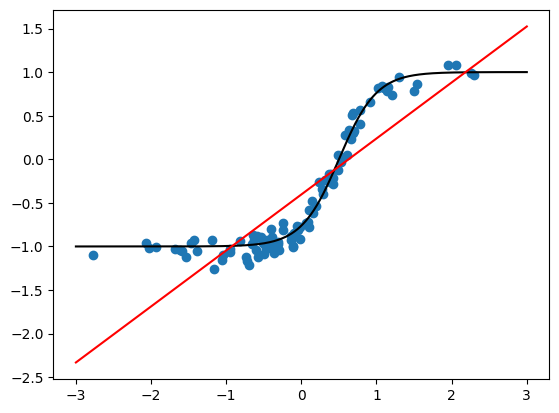

In [29]:
Phi = np.column_stack([x, np.ones_like(x)])
w = my_pinv_thinSVD(Phi) @ y

print(w)

# This builds the design matrix for new x-values (test points).
Phi_test = np.column_stack([x_test, np.ones_like(x_test)])

plt.scatter(x, y)
plt.plot(x_test, y_test, "k")
plt.plot(x_test, Phi_test @ w, 'r')

| Code           | Mathematical meaning          |
| -------------- | ----------------------------- |
| `Phi = [x, 1]` | build linear model basis      |
| `Phi†`         | pseudoinverse (least squares) |
| `w = Phi† y`   | estimate (m,q)                |
| `Phi_test`     | apply same model to new data  |
| `Phi_test @ w` | predictions                   |


# Ridge Regression

Let us now consider **ridge regression**, corresponding to a regularizaton parameter $\lambda = 1.0$.
Solve the equations in two ways:
1. Using the normal equations
$$[(\Phi^T \Phi) + \lambda I] \mathbf{w} = \Phi^T \mathbf{y}$$
2. Using the Woodbury idenitity to write the normal equations in "kernel-form"
$$\mathbf{w} = \Phi^T \boldsymbol{\alpha}, \quad [(\Phi \Phi^T) + \lambda I] \boldsymbol{\alpha} = \mathbf{y}$$

Check that the two approaches lead to the same result.
Compare the obtained regression line with the one obtained through least squares regression when changing $\lambda$.


[ 0.63557122 -0.40013185]
[ 0.63557122 -0.40013185]
5.551115123125783e-16


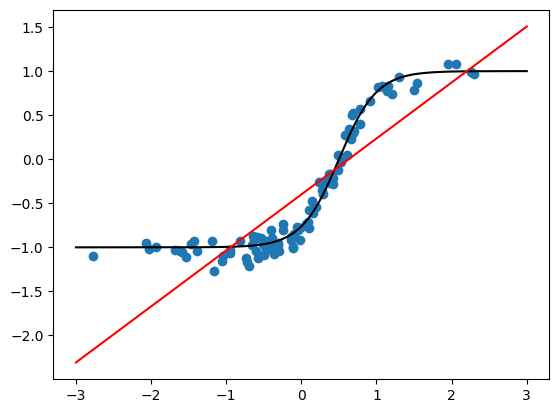

In [30]:
lam = 1.0
# Phi.T @ Phi
# (2xN)   (NX2), therefore I size is 2
w = np.linalg.solve(Phi.T @ Phi + lam* np.eye(2), Phi.T @ y) # in numpy Identity is called eye
y_pred = Phi_test @ w
print(w)

# woodbury identity
alpha = np.linalg.solve(Phi @ Phi.T + lam * np.eye(N), y)
w2 = Phi.T @ alpha
print(w2)
print(np.linalg.norm(w-w2))

plt.scatter(x, y)
plt.plot(x_test, y_test, 'k')
plt.plot(x_test, y_pred, 'r')

Consider now **kernel regression**.

$$(K + \lambda I) \boldsymbol{\alpha} = \mathbf{y}$$

Where $K_{ij} = \mathcal{K}(x_i, x_j)$ and we consider

1. The scalar product kernel
   $$\mathcal{K}(x_i, x_j) = x_i x_j + 1.$$

2. The higher-order scalar product kernel, for $q > 1$.
   $$\mathcal{K}(x_i, x_j) = (x_i x_j + 1)^q.$$

3. The Gaussian kernel, for $\sigma > 0$.
   $$\mathcal{K}(x_i, x_j) = \exp\left(-\frac{(x_i - x_j)^2}{2 \sigma^2}\right).$$


The evaluation on the test data-point $\hat{x}$ is computed as

$$\hat{\mathbf{y}} = \sum_{i = 1}^N \alpha_i \mathcal{K}(\hat{x}, x_i) = K^{Test} \boldsymbol{\alpha}$$


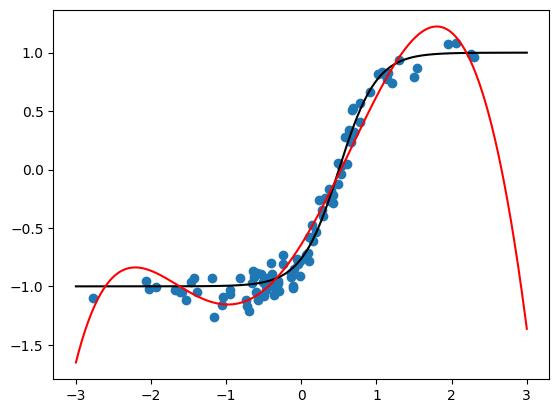

In [38]:
# K - product kernel
# defining 3 functions for each mentioned above

lam = 1.0 #regularization term
q = 4 #polynomial kernel degree
sigma = 1.0 #distance normalized by sigma, larger sigma larger variance

def product_kernel(x1, x2):
  return x1 * x2 + 1

def high_order_kernel(x1, x2):
  return (x1+ x2+ 1)**q

def gaussian_kernel(x1, x2):
  return np.exp(-((x1-x2)/sigma)**2/2)

def kernel_regression(kernel): #takes 2 points and returns 1 scalar
  N = x.shape[0]
  K = np.empty((N, N))
  for i in range(N):
    for j in range(N):
      K[i, j] = kernel(x[i], x[j])
  alpha = np.linalg.solve(K + lam * np.eye(N), y)
  K_test = np.empty((x_test.shape[0], N)) #y hat
  for i in range(K_test.shape[0]):
    for j in range(K_test.shape[1]):
      K_test[i, j] = kernel(x_test[i], x[j])
  return K_test @ alpha

plt.scatter(x, y)
plt.plot(x_test, y_test, 'k')
y_pred = kernel_regression(high_order_kernel)
plt.plot(x_test, y_pred, 'r')

As an advance homework, try to write the matrix $K$ without using a for loop.
Hint: you have to rewrite the kernel function $\mathcal{K}$ to work with matrices.

In [39]:
# refer solution notebook

